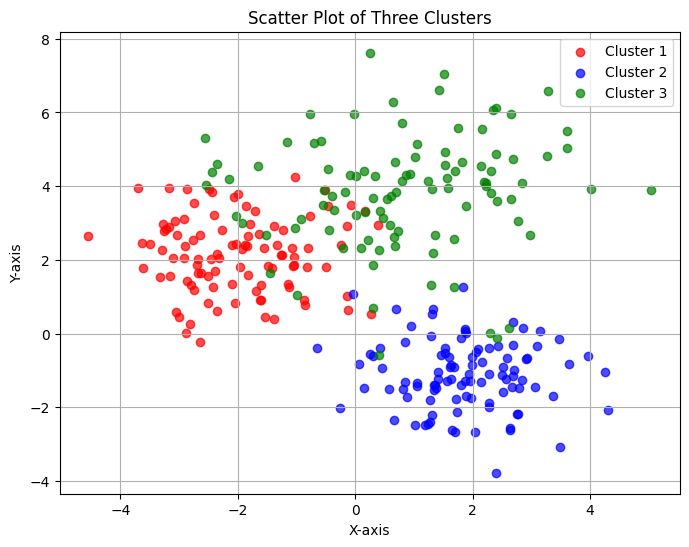

In [ ]:
# prompt: 請隨機產生300個點，這些點可以分三群請運用np.normal，并且呈現散步圖，不同的群請用不同的顔色表達

import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(0)

# Generate data for three clusters
n_points = 100
cluster1 = np.random.normal(loc=[-2, 2], scale=1, size=(n_points, 2))
cluster2 = np.random.normal(loc=[2, -1], scale=1, size=(n_points, 2))
cluster3 = np.random.normal(loc=[1, 4], scale=1.5, size=(n_points, 2))


# Combine the clusters into a single dataset
data = np.concatenate((cluster1, cluster2, cluster3))

# Create the plot
plt.figure(figsize=(8, 6))
plt.scatter(cluster1[:, 0], cluster1[:, 1], label='Cluster 1', c='red', alpha=0.7)
plt.scatter(cluster2[:, 0], cluster2[:, 1], label='Cluster 2', c='blue', alpha=0.7)
plt.scatter(cluster3[:, 0], cluster3[:, 1], label='Cluster 3', c='green', alpha=0.7)

plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('Scatter Plot of Three Clusters')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# prompt: 請計算以上每群的SSE

import numpy as np

# Calculate centroids for each cluster (replace with your actual centroids)
centroid1 = np.mean(cluster1, axis=0)
centroid2 = np.mean(cluster2, axis=0)
centroid3 = np.mean(cluster3, axis=0)

# Calculate SSE for each cluster
sse1 = np.sum((cluster1 - centroid1)**2)
sse2 = np.sum((cluster2 - centroid2)**2)
sse3 = np.sum((cluster3 - centroid3)**2)

print(f"SSE for Cluster 1: {sse1}")
print(f"SSE for Cluster 2: {sse2}")
print(f"SSE for Cluster 3: {sse3}")

# Calculate total SSE
total_sse = sse1 + sse2 + sse3
print(f"Total SSE: {total_sse}")


SSE for Cluster 1: 207.62788756811256
SSE for Cluster 2: 177.9018072908072
SSE for Cluster 3: 478.810822932213
Total SSE: 864.3405177911327


In [ ]:
type(data)

numpy.ndarray

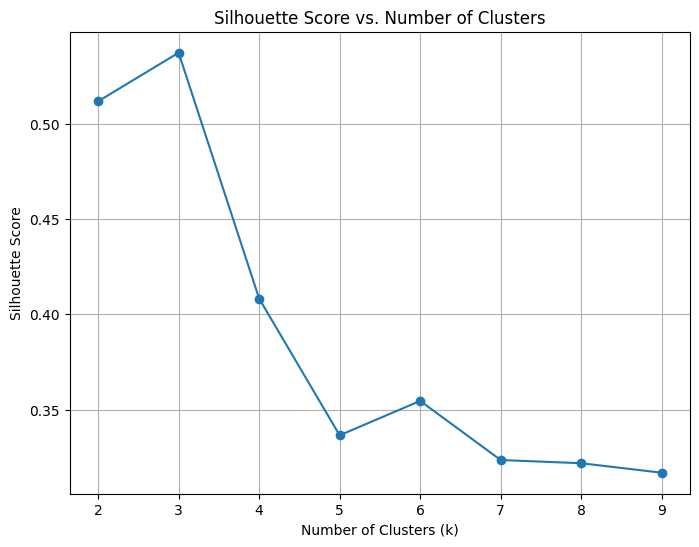

Optimal number of clusters (k): 3


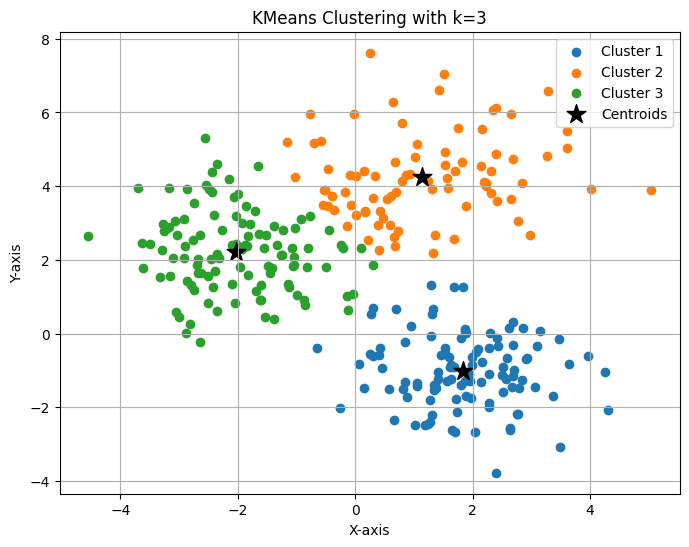

In [ ]:
# prompt: 針對data進行kmeans，并且用輪廓係數得到最佳的分組組數，繪製輪廓係數與k值來得到曲綫圖

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ... (Your existing code for data generation) ...

# Determine optimal number of clusters using silhouette score
silhouette_scores = []
k_values = range(2, 10)  # Test k values from 2 to 9

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(data)
    labels = kmeans.labels_
    silhouette_avg = silhouette_score(data, labels)
    silhouette_scores.append(silhouette_avg)

# Plot silhouette scores
plt.figure(figsize=(8, 6))
plt.plot(k_values, silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs. Number of Clusters')
plt.grid(True)
plt.show()

# Find the best k based on the highest silhouette score
best_k = k_values[np.argmax(silhouette_scores)]
print(f"Optimal number of clusters (k): {best_k}")

# Apply KMeans with the best k
kmeans = KMeans(n_clusters=best_k, random_state=0)
kmeans.fit(data)
labels = kmeans.labels_

# Visualize the clusters
plt.figure(figsize=(8, 6))
for i in range(best_k):
    plt.scatter(data[labels == i, 0], data[labels == i, 1], label=f'Cluster {i+1}')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, c='black', marker='*', label='Centroids')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title(f'KMeans Clustering with k={best_k}')
plt.legend()
plt.grid(True)
plt.show()


In [19]:
# prompt: 將分群結果（每一點的數值以及所屬的分群）匯出成excel，檔名為keans_result113

import pandas as pd

# Assuming 'data' and 'labels' are already defined from your KMeans clustering

# Create a DataFrame with the data points and their cluster assignments
df_result = pd.DataFrame(data, columns=['X', 'Y'])  # Assuming your data has two columns
df_result['Cluster'] = labels

# Export the DataFrame to an Excel file
df_result.to_excel('keans_result113.xlsx', index=False)
